<a href="https://colab.research.google.com/github/Deepikadandolu/SumInt_IISc_ex1/blob/main/Chest_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [2]:
# Define classes and labels
classes = {
    'NORMAL': 0,
    'PNEUMONIA': 1}
# Dataset training folder path
train_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
# Load and preprocess dataset
X = []
Y = []
for cls, label in classes.items():
    class_path = os.path.join(train_path, cls)
    for filename in os.listdir(class_path):
        img_path = os.path.join(class_path, filename)
        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Resize image
            img = cv2.resize(img, (200, 200))
            # Normalize image
            img = img / 255.0
            # CNN requires image shape, not flattening
            X.append(img)
            # Append label
            Y.append(label)
# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)
# Reshape for CNN
X = X.reshape(-1, 200, 200, 1)
# Convert labels to categorical
Y = to_categorical(Y, num_classes=2)
print("Dataset loaded successfully")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Dataset loaded successfully
X shape: (5216, 200, 200, 1)
Y shape: (5216, 2)


In [3]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.2,
    stratify=Y)
print("Training Shape :", xtrain.shape)
print("Testing Shape  :", xtest.shape)
# Build CNN model
cnn_model = Sequential([
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(200, 200, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(
        64,
        (3, 3),
        activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(
        128,
        (3, 3),
        activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')])
# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
# Train model
history = cnn_model.fit(
    xtrain,
    ytrain,
    epochs=10,
    batch_size=32,
    validation_data=(xtest, ytest))
# Evaluate model
train_loss, train_score = cnn_model.evaluate(
    xtrain,
    ytrain,
    verbose=0)
test_loss, test_score = cnn_model.evaluate(
    xtest,
    ytest,
    verbose=0)

print("\nCNN Results")
print("80-20 Split")
print("Training Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

Training Shape : (4172, 200, 200, 1)
Testing Shape  : (1044, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.8780 - loss: 0.2884 - val_accuracy: 0.9320 - val_loss: 0.1495
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9487 - loss: 0.1387 - val_accuracy: 0.9521 - val_loss: 0.1193
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9688 - loss: 0.1006 - val_accuracy: 0.9588 - val_loss: 0.1047
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9691 - loss: 0.0879 - val_accuracy: 0.9598 - val_loss: 0.0968
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9744 - loss: 0.0825 - val_accuracy: 0.9646 - val_loss: 0.0892
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9777 - loss: 0.0635 - val_accuracy: 0.9598 - val_loss: 0.0928
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9799 - loss: 0.0570 - val_accuracy: 0.9607 - val_loss: 0.1167
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9837 - loss: 0.0436 - val_ac

In [4]:
# Split the dataset 40-60
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.6,
    stratify=Y)
print("Training Data Shape :", xtrain.shape)
print("Testing Data Shape  :", xtest.shape)
# Build CNN model
cnn_model = Sequential([
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(200, 200, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(
        64,
        (3, 3),
        activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(
        128,
        (3, 3),
        activation='relu' ),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')])
# Compile CNN
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
# Train CNN
history = cnn_model.fit(
    xtrain,
    ytrain,
    epochs=10,
    batch_size=32,
    validation_data=(xtest, ytest))
# Evaluate CNN
train_loss, train_score = cnn_model.evaluate(
    xtrain,
    ytrain,
    verbose=0)
test_loss, test_score = cnn_model.evaluate(
    xtest,
    ytest,
    verbose=0)
print("\n40-60 Split")
print("\nCNN Results")
print("Training Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

Training Data Shape : (2086, 200, 200, 1)
Testing Data Shape  : (3130, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 187ms/step - accuracy: 0.8265 - loss: 0.4103 - val_accuracy: 0.9403 - val_loss: 0.1605
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9291 - loss: 0.1905 - val_accuracy: 0.9450 - val_loss: 0.1309
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9525 - loss: 0.1307 - val_accuracy: 0.9399 - val_loss: 0.1460
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9588 - loss: 0.1137 - val_accuracy: 0.9629 - val_loss: 0.0966
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9698 - loss: 0.0844 - val_accuracy: 0.9636 - val_loss: 0.0940
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9732 - loss: 0.0786 - val_accuracy: 0.9601 - val_loss: 0.1192
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9784 - loss: 0.0659 - val_accuracy: 0.9665 - val_loss: 0.0933
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9813 - loss: 0.0504 - val_accuracy: 0.9581 -

In [5]:
# Split the dataset into 60-40
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.4,
    stratify=np.argmax(Y, axis=1))
print("Training Data Shape :", xtrain.shape)
print("Testing Data Shape  :", xtest.shape)
# Build CNN model
cnn_model = Sequential([
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(200, 200, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(
        64,
        (3, 3),
        activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(
        128,
        (3, 3),
        activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')])
# Compile CNN model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
# Train CNN model
history = cnn_model.fit(
    xtrain,
    ytrain,
    epochs=10,
    batch_size=32,
    validation_data=(xtest, ytest))
# Evaluate model
train_loss, train_score = cnn_model.evaluate(
    xtrain,
    ytrain,
    verbose=0)
test_loss, test_score = cnn_model.evaluate(
    xtest,
    ytest,
    verbose=0)
print("\n60-40 Split")
print("\nCNN Results")
print("Training Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

Training Data Shape : (3129, 200, 200, 1)
Testing Data Shape  : (2087, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.8686 - loss: 0.3317 - val_accuracy: 0.9516 - val_loss: 0.1387
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9354 - loss: 0.1700 - val_accuracy: 0.9521 - val_loss: 0.1632
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9543 - loss: 0.1415 - val_accuracy: 0.9669 - val_loss: 0.0909
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9639 - loss: 0.0995 - val_accuracy: 0.9703 - val_loss: 0.0812
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9703 - loss: 0.0803 - val_accuracy: 0.9684 - val_loss: 0.0812
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9786 - loss: 0.0616 - val_accuracy: 0.9617 - val_loss: 0.0999
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9792 - loss: 0.0594 - val_accuracy: 0.9684 - val_loss: 0.0823
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9859 - loss: 0.0398 - val_accuracy: 0.9708 -

In [6]:
# Split the dataset into 20-80
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.8,
    stratify=np.argmax(Y, axis=1))
print("Training Data Shape :", xtrain.shape)
print("Testing Data Shape  :", xtest.shape)
# Build CNN model
cnn_model = Sequential([
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(200, 200, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(
        64,
        (3, 3),
        activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(
        128,
        (3, 3),
        activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')])
# Compile CNN model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
# Train CNN model
history = cnn_model.fit(
    xtrain,
    ytrain,
    epochs=10,
    batch_size=32,
    validation_data=(xtest, ytest))
# Evaluate model
train_loss, train_score = cnn_model.evaluate(
    xtrain,
    ytrain,
    verbose=0)
test_loss, test_score = cnn_model.evaluate(
    xtest,
    ytest,
    verbose=0)
print("\n20-80 Split")
print("\nCNN Results")
print("Training Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

Training Data Shape : (1043, 200, 200, 1)
Testing Data Shape  : (4173, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 311ms/step - accuracy: 0.7392 - loss: 0.6358 - val_accuracy: 0.8775 - val_loss: 0.3675
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8869 - loss: 0.2941 - val_accuracy: 0.9377 - val_loss: 0.1648
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9338 - loss: 0.1649 - val_accuracy: 0.9322 - val_loss: 0.1829
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9492 - loss: 0.1516 - val_accuracy: 0.9526 - val_loss: 0.1341
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9492 - loss: 0.1413 - val_accuracy: 0.9322 - val_loss: 0.1769
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9597 - loss: 0.1177 - val_accuracy: 0.9535 - val_loss: 0.1310
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9569 - loss: 0.1101 - val_accuracy: 0.9552 - val_loss: 0.1230
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9722 - loss: 0.0872 - val_accuracy: 0.9621 -

In [7]:
# Display sample images and CNN predictions
def display_samples(folder, title, model, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for filename in os.listdir(folder)[:num_samples]:
        img_path = os.path.join(folder, filename)
        # Read image in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Resize image
            img = cv2.resize(img, (200, 200))
            # Normalize image
            img_normalized = img / 255.0
            # Reshape for CNN
            img_input = img_normalized.reshape(1, 200, 200, 1)
            # Predict
            prediction = model.predict(img_input, verbose=0)
            predicted_class = np.argmax(prediction)
            # Label names
            predicted_label = (
                "NORMAL"
                if predicted_class == 0
                else "PNEUMONIA")
            # Display image
            plt.subplot(3, 3, c)
            plt.title(predicted_label)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            c += 1
    plt.suptitle(title)
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - accuracy: 0.7114 - loss: 0.6703 - val_accuracy: 0.8191 - val_loss: 0.4251
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8686 - loss: 0.3208 - val_accuracy: 0.9274 - val_loss: 0.2113
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9214 - loss: 0.2017 - val_accuracy: 0.9504 - val_loss: 0.1358
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9492 - loss: 0.1371 - val_accuracy: 0.9521 - val_loss: 0.1324
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.9434 - loss: 0.1281 - val_accuracy: 0.9530 - val_loss: 0.1349
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9636 - loss: 0.1001 - val_accuracy: 0.9576 - val_loss: 0.1138
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9655 - loss: 0.0986 - val_accuracy: 0.9595 - val_loss: 0.1234
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9636 - loss: 0.0859 - val_accuracy: 0.9542 -

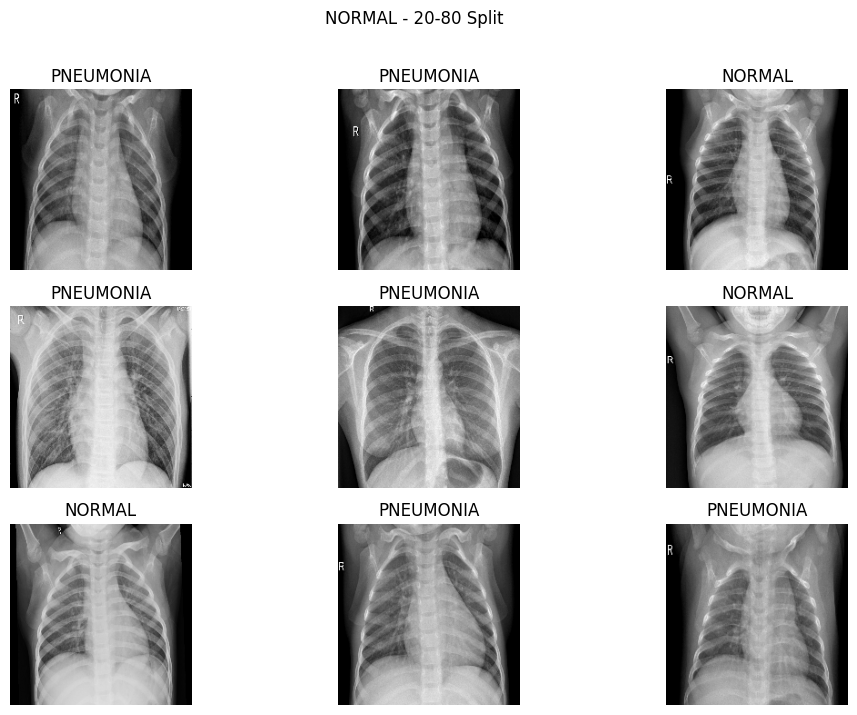

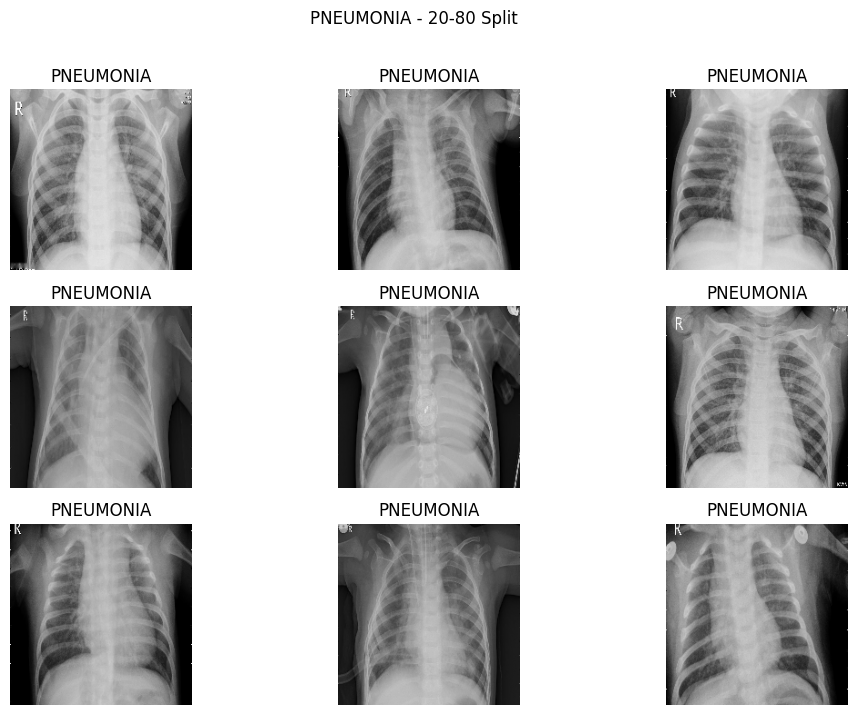

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.8193 - loss: 0.4096 - val_accuracy: 0.9409 - val_loss: 0.1664
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9276 - loss: 0.1821 - val_accuracy: 0.9578 - val_loss: 0.1279
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9506 - loss: 0.1396 - val_accuracy: 0.9565 - val_loss: 0.1111
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9578 - loss: 0.1219 - val_accuracy: 0.9540 - val_loss: 0.1172
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9573 - loss: 0.1189 - val_accuracy: 0.9665 - val_loss: 0.0985
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9674 - loss: 0.0909 - val_accuracy: 0.9700 - val_loss: 0.0859
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9741 - loss: 0.0774 - val_accuracy: 0.9677 - val_loss: 0.0909
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9751 - loss: 0.0702 - val_accuracy: 0.9677 -

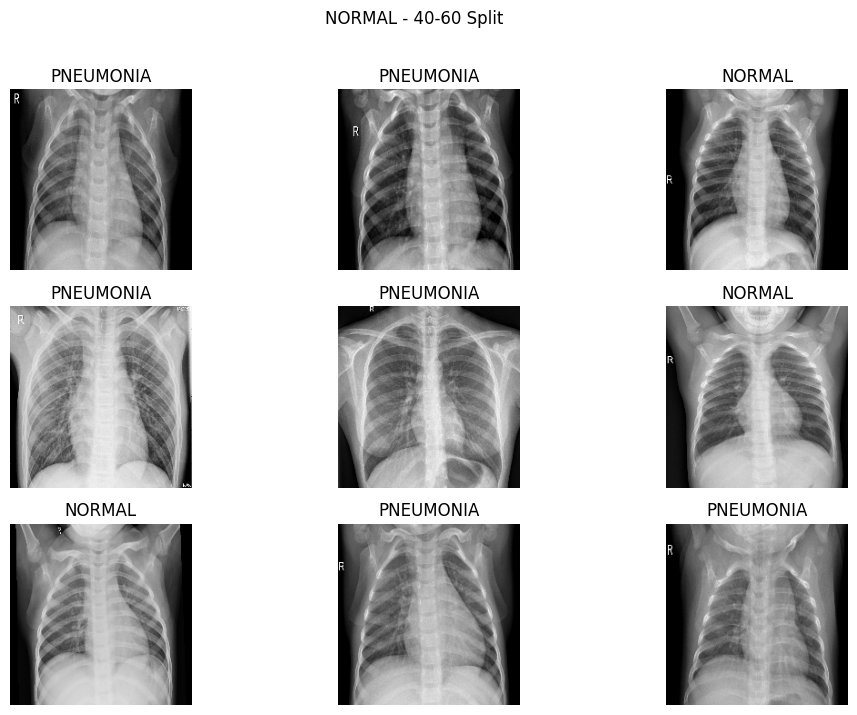

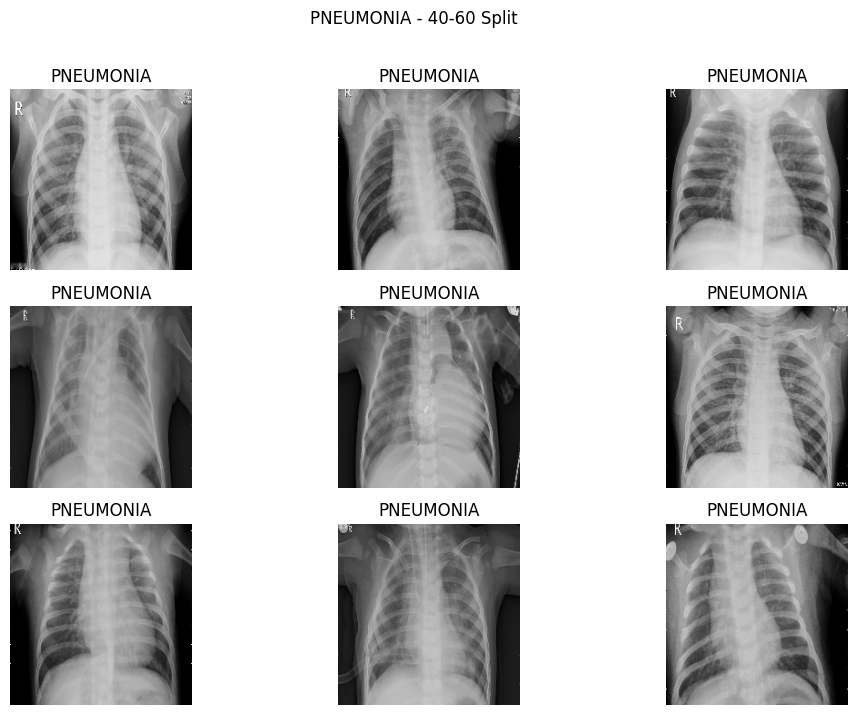

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8779 - loss: 0.3043 - val_accuracy: 0.9550 - val_loss: 0.1258
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9473 - loss: 0.1356 - val_accuracy: 0.9607 - val_loss: 0.1059
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9514 - loss: 0.1320 - val_accuracy: 0.9645 - val_loss: 0.1081
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9629 - loss: 0.0952 - val_accuracy: 0.9674 - val_loss: 0.0852
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9716 - loss: 0.0740 - val_accuracy: 0.9540 - val_loss: 0.1155
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9757 - loss: 0.0706 - val_accuracy: 0.9641 - val_loss: 0.1052
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9770 - loss: 0.0616 - val_accuracy: 0.9660 - val_loss: 0.0970
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9831 - loss: 0.0497 - val_accuracy: 0.9698 - 

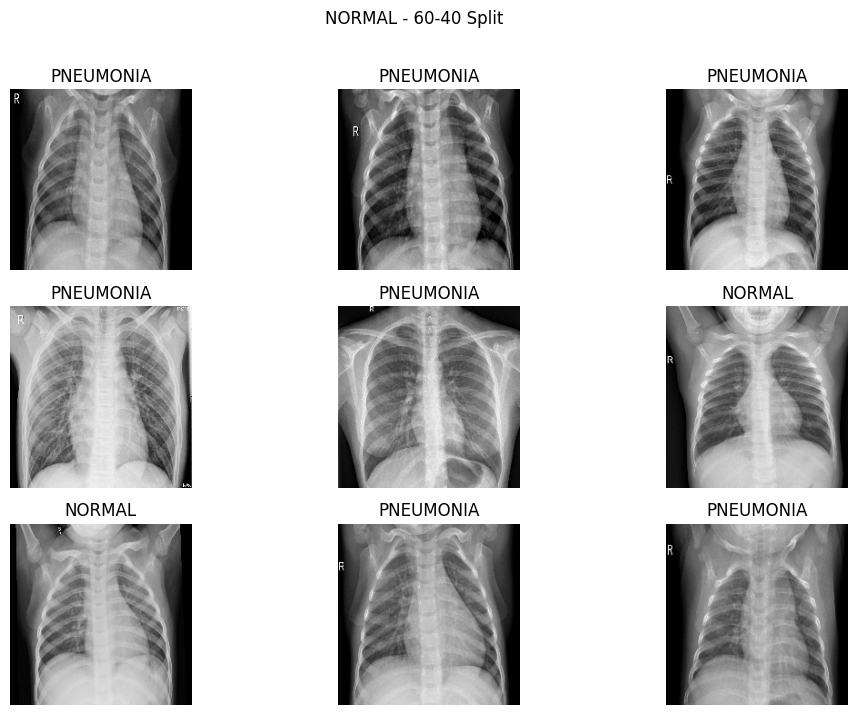

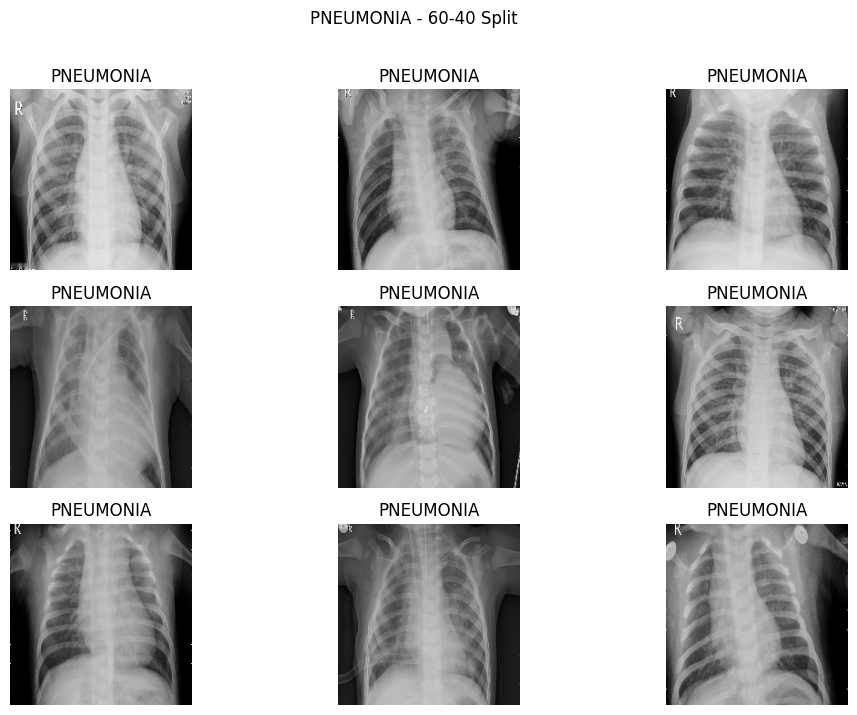

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8588 - loss: 0.3290 - val_accuracy: 0.9444 - val_loss: 0.1398
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9463 - loss: 0.1473 - val_accuracy: 0.9569 - val_loss: 0.1025
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9583 - loss: 0.1076 - val_accuracy: 0.9435 - val_loss: 0.1386
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9684 - loss: 0.0970 - val_accuracy: 0.9713 - val_loss: 0.0928
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9681 - loss: 0.0848 - val_accuracy: 0.9703 - val_loss: 0.0675
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9772 - loss: 0.0633 - val_accuracy: 0.9770 - val_loss: 0.0628
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9794 - loss: 0.0564 - val_accuracy: 0.9741 - val_loss: 0.0606
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9844 - loss: 0.0500 - val_acc

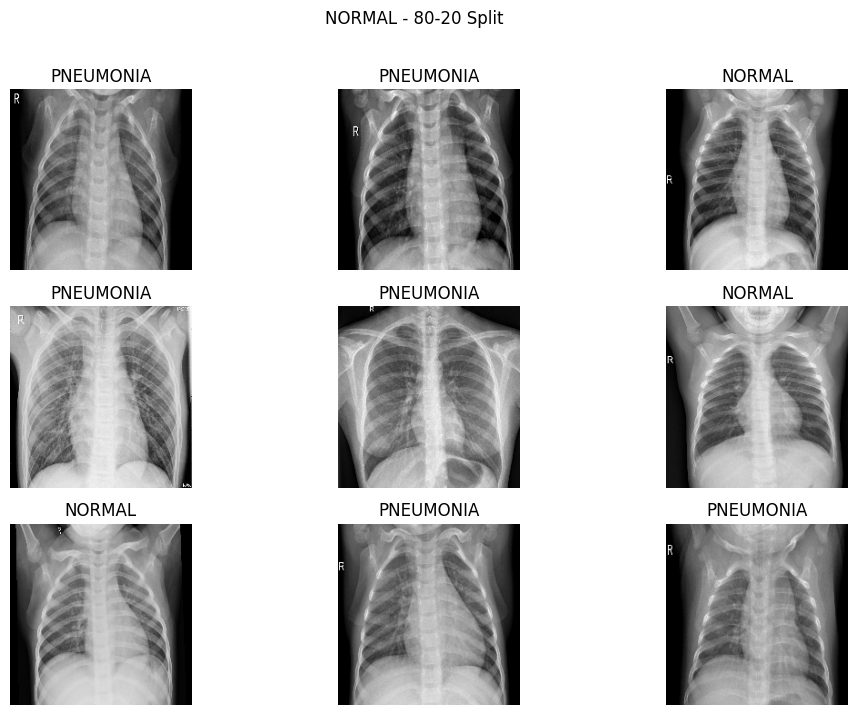

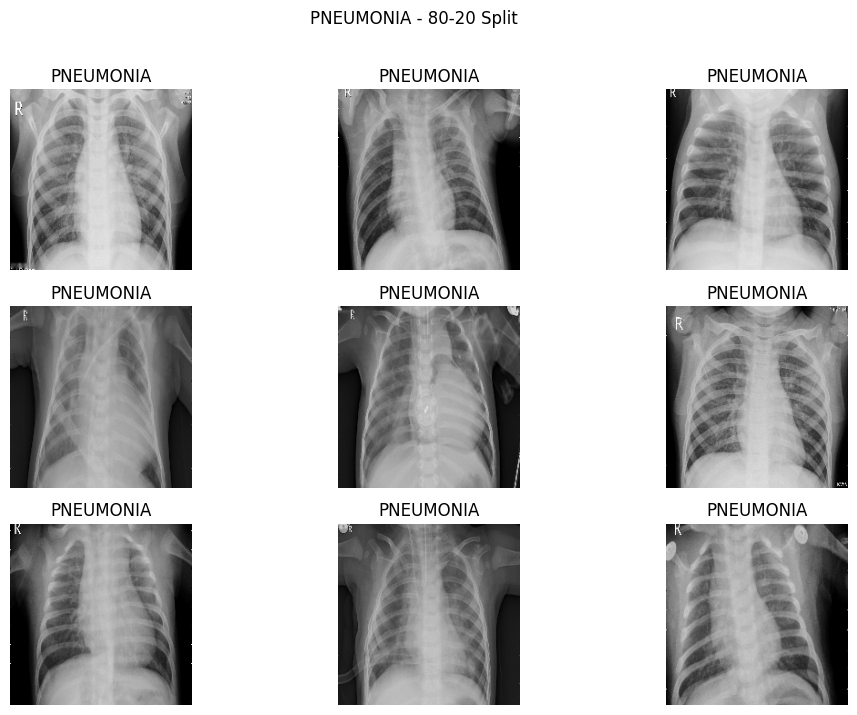

In [8]:
# Define class labels
dec = {
    0: 'NORMAL',
    1: 'PNEUMONIA'}
# Get testing dataset path
test_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
# Different train-test splits
splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2}
# Chest X-ray folders
xray_folders = [
    'NORMAL',
    'PNEUMONIA']
for split_name, test_size in splits.items():
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=42,
        test_size=test_size,
        stratify=np.argmax(Y, axis=1))
    # Build CNN model
    cnn_model = Sequential([
        Conv2D(
            32,
            (3, 3),
            activation='relu',
            input_shape=(200, 200, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(
            64,
            (3, 3),
            activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(
            128,
            (3, 3),
            activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')])
    # Compile CNN
    cnn_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    # Train CNN
    cnn_model.fit(
        xtrain,
        ytrain,
        epochs=10,
        batch_size=32,
        validation_data=(xtest, ytest),
        verbose=1)
    print(f"\nPredictions using CNN - {split_name}")
    # Display predictions
    for xray_folder in xray_folders:
        folder_path = os.path.join(
            test_path,
            xray_folder)
        title = f'{xray_folder} - {split_name}'
        display_samples(
            folder_path,
            title,
            cnn_model)

In [9]:
import pandas as pd
# Different train-test splits
splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2}
for split_name, test_size in splits.items():
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=42,
        test_size=test_size,
        stratify=np.argmax(Y, axis=1))
    # Convert one-hot labels back to integers
    ytrain_labels = np.argmax(ytrain, axis=1)
    # Count class samples
    xray_counts = {
        dec[label]: np.sum(ytrain_labels == label)
        for label in classes.values()}
    # Create table
    table_data = {
        'Index': range(1, len(classes) + 1),
        'Chest X-Ray Class': list(xray_counts.keys()),
        'Count': list(xray_counts.values())}
    xray_table = pd.DataFrame(table_data)
    # Style table
    styled_table = xray_table.style.set_properties(
        **{
            'border': '3px solid black',
            'text-align': 'center'})
    print(f"\nChest X-Ray Class Counts - {split_name}")
    display(styled_table)


Chest X-Ray Class Counts - 20-80 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,268
1,2,PNEUMONIA,775



Chest X-Ray Class Counts - 40-60 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,536
1,2,PNEUMONIA,1550



Chest X-Ray Class Counts - 60-40 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,804
1,2,PNEUMONIA,2325



Chest X-Ray Class Counts - 80-20 Split


,Index,Chest X-Ray Class,Count
0,1,NORMAL,1073
1,2,PNEUMONIA,3099


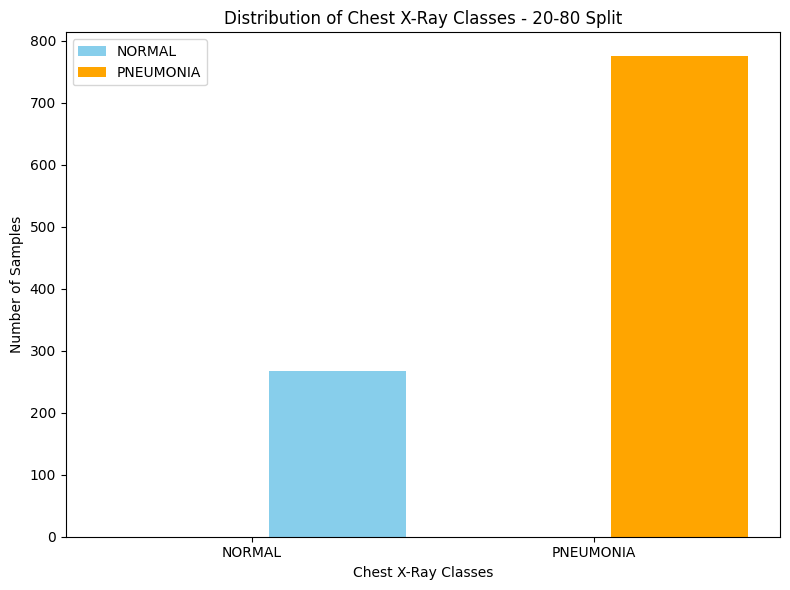

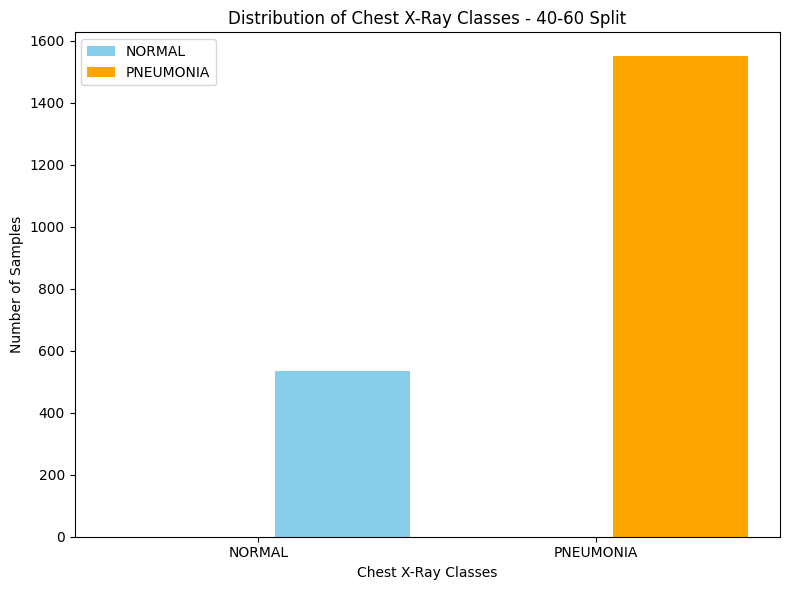

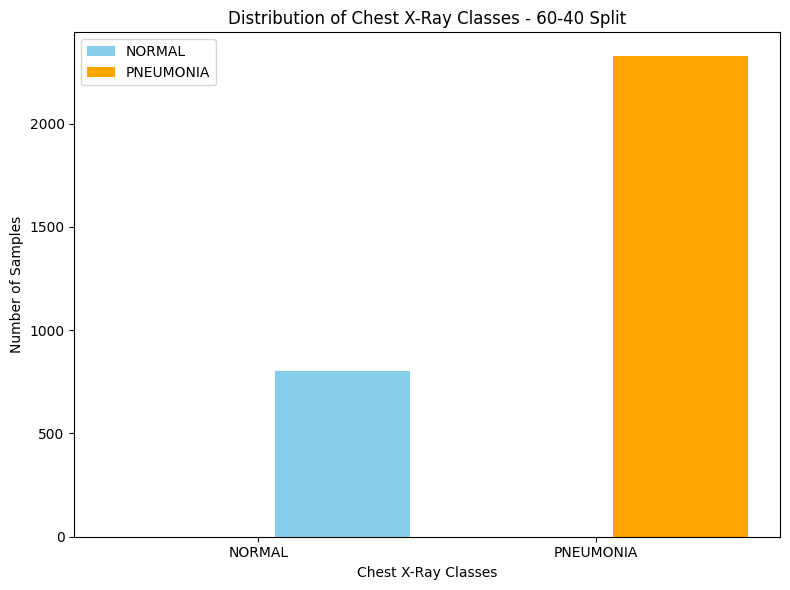

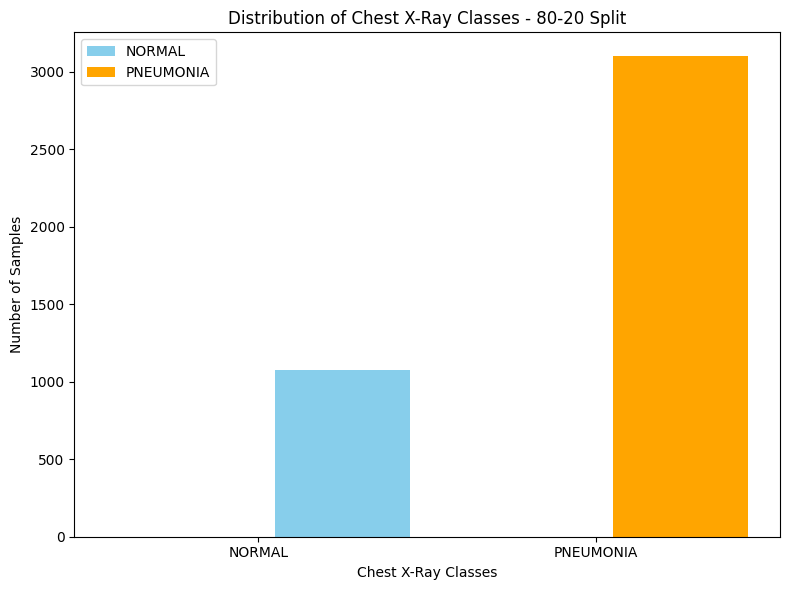

In [10]:
# Create histogram of Chest X-ray classes for different train-test split
colors = ['skyblue', 'orange']
splits = {
    "20-80 Split": 0.8,
    "40-60 Split": 0.6,
    "60-40 Split": 0.4,
    "80-20 Split": 0.2
}
for split_name, test_size in splits.items():
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=42,
        test_size=test_size,
        stratify=np.argmax(Y, axis=1))
    # Convert one-hot labels to integer labels
    ytrain_labels = np.argmax(ytrain, axis=1)
    # Convert labels to class names
    xray_labels = [dec[label] for label in ytrain_labels]
    plt.figure(figsize=(8, 6))
    for label, color in zip(classes.values(), colors):
        plt.hist(
            np.array(xray_labels)[ytrain_labels == label],
            bins=len(classes),
            align='mid',
            rwidth=0.8,
            color=color,
            label=dec[label])
    plt.xlabel('Chest X-Ray Classes')
    plt.ylabel('Number of Samples')
    plt.title(
        f'Distribution of Chest X-Ray Classes - {split_name}')
    plt.xticks(
        range(len(classes)),
        list(classes.keys()),
        rotation=0)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
train_sizes = [0.2, 0.4, 0.6, 0.8]
for train_size in train_sizes:
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=42,
        stratify=np.argmax(Y, axis=1))
    print(f"\nTraining Size : {int(train_size * 100)}%")
    print("Training Shape:", xtrain.shape)
    print("Testing Shape :", xtest.shape)
    # Build CNN model
    cnn_model = Sequential([
        Conv2D(
            32,
            (3, 3),
            activation='relu',
            input_shape=(200, 200, 1) ),
        MaxPooling2D((2, 2)),
        Conv2D(
            64,
            (3, 3),
            activation='relu'
        ),
        MaxPooling2D((2, 2)),
        Conv2D(
            128,
            (3, 3),
            activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')])
    # Compile CNN
    cnn_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    # Train CNN
    cnn_model.fit(
        xtrain,
        ytrain,
        epochs=10,
        batch_size=32,
        validation_data=(xtest, ytest),
        verbose=0)
    # Predictions
    ypred_prob = cnn_model.predict(xtest, verbose=0)
    ypred_cnn = np.argmax(ypred_prob, axis=1)
    ytest_labels = np.argmax(ytest, axis=1)
    # Metrics
    accuracy_cnn = accuracy_score(
        ytest_labels,
        ypred_cnn )
    f1_cnn = f1_score(
        ytest_labels,
        ypred_cnn,
        average='weighted' )

    cm_cnn = confusion_matrix(
        ytest_labels,
        ypred_cnn )

    sensitivity_cnn = np.mean(
        cm_cnn.diagonal() / cm_cnn.sum(axis=1))

    specificity_cnn = np.mean([
        ( np.sum(cm_cnn) -
            (
                cm_cnn[i, :].sum() +
                cm_cnn[:, i].sum() -
                cm_cnn[i, i]
            )
        ) /
        (
            np.sum(cm_cnn) -
            cm_cnn[i, :].sum())
        for i in range(len(cm_cnn))])
    print(
        f"\nCNN Results "
        f"({int(train_size*100)}-"
        f"{int((1-train_size)*100)} Split)")
    print("Accuracy   :", accuracy_cnn)
    print("F1-Score   :", f1_cnn)
    print("Sensitivity:", sensitivity_cnn)
    print("Specificity:", specificity_cnn)


Training Size : 20%
Training Shape: (1043, 200, 200, 1)
Testing Shape : (4173, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Results (20-80 Split)
Accuracy   : 0.9657320872274143
F1-Score   : 0.9657992544999009
Sensitivity: 0.9571304452394552
Specificity: 0.9571304452394552

Training Size : 40%
Training Shape: (2086, 200, 200, 1)
Testing Shape : (3130, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Results (40-60 Split)
Accuracy   : 0.9706070287539936
F1-Score   : 0.9704348792479691
Sensitivity: 0.9558511988245508
Specificity: 0.9558511988245508

Training Size : 60%
Training Shape: (3129, 200, 200, 1)
Testing Shape : (2087, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Results (60-40 Split)
Accuracy   : 0.9693339722089123
F1-Score   : 0.9693339722089123
Sensitivity: 0.9598822610680603
Specificity: 0.9598822610680603

Training Size : 80%
Training Shape: (4172, 200, 200, 1)
Testing Shape : (1044, 200, 200, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Results (80-19 Split)
Accuracy   : 0.9703065134099617
F1-Score   : 0.97063076978051
Sensitivity: 0.9726977227265734
Specificity: 0.9726977227265734


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

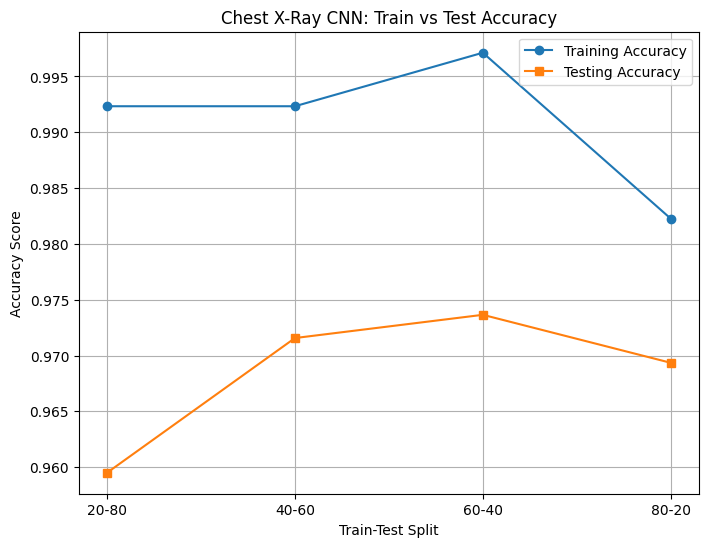

In [12]:
train_sizes = [0.2, 0.4, 0.6, 0.8]
split_labels = ['20-80', '40-60', '60-40', '80-20']
train_scores = []
test_scores = []

for train_size in train_sizes:
    # Split dataset
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=42,
        stratify=np.argmax(Y, axis=1) )

    # Build CNN model
    cnn_model = Sequential([
        Conv2D(
            32,
            (3, 3),
            activation='relu',
            input_shape=(200, 200, 1)
        ),

        MaxPooling2D((2, 2)),
        Conv2D(
            64,
            (3, 3),
            activation='relu'
        ),
        MaxPooling2D((2, 2)),
        Conv2D(
            128,
            (3, 3),
            activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')])
    # Compile CNN
    cnn_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    # Train CNN
    cnn_model.fit(
        xtrain,
        ytrain,
        epochs=10,
        batch_size=32,
        validation_data=(xtest, ytest),
        verbose=0)
    # Evaluate CNN
    train_loss, train_score = cnn_model.evaluate(
        xtrain,
        ytrain,
        verbose=0)
    test_loss, test_score = cnn_model.evaluate(
        xtest,
        ytest,
        verbose=0)
    train_scores.append(train_score)
    test_scores.append(test_score)
# Plot graph
plt.figure(figsize=(8, 6))
plt.plot(
    split_labels,
    train_scores,
    marker='o',
    label='Training Accuracy')
plt.plot(
    split_labels,
    test_scores,
    marker='s',
    label='Testing Accuracy')
plt.xlabel('Train-Test Split')
plt.ylabel('Accuracy Score')
plt.title('Chest X-Ray CNN: Train vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [18]:

splits = {
    "20_80": 0.8,
    "40_60": 0.6,
    "60_40": 0.4,
    "80_20": 0.2}
for split_name, test_size in splits.items():
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        random_state=10,
        test_size=test_size)
    model = Sequential([
        Input(shape=(200, 200, 1)),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    model.fit(
        xtrain,
        ytrain,
        epochs=5,
        batch_size=32)
    # Save model
    model.save(f"cnn_model_{split_name}.h5")
    print(f"Saved model: cnn_model_{split_name}.h5")

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.7824 - loss: 0.5617
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9166 - loss: 0.2150
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9511 - loss: 0.1424
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9578 - loss: 0.1004
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9799 - loss: 0.0609


Saved model: cnn_model_20_80.h5
Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8408 - loss: 0.5867
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9406 - loss: 0.1519
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9640 - loss: 0.1014
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9569 - loss: 0.1154
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9636 - loss: 0.0985


Saved model: cnn_model_40_60.h5
Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.8693 - loss: 0.3875
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9466 - loss: 0.1421
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9498 - loss: 0.1322
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9664 - loss: 0.0928
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9767 - loss: 0.0716


Saved model: cnn_model_60_40.h5
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9003 - loss: 0.2650
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9547 - loss: 0.1219
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9648 - loss: 0.0953
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9734 - loss: 0.0743
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9698 - loss: 0.0752


Saved model: cnn_model_80_20.h5
